> **Versão pública.** Este notebook rodou no Google Colab, com os dados e artefatos numa pasta do Google Drive do grupo. Para reproduzir, veja [Como reproduzir](../README.md#como-reproduzir).

# Imports e Configuração de Ambiente

In [ ]:
#https://github.com/laurahanu/2D-and-3D-Deep-Autoencoder
path_notebook = '/content/drive/My Drive/<PASTA_DO_PROJETO>/Notebooks_Alexandre/04-Autoencoder/'

In [ ]:
from google.colab import drive

import os
import sys

import pandas as pd
import numpy as np
from PIL import Image, ImageOps

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import gc

import tensorflow as tf

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight

from sklearn import metrics

import matplotlib.cm as cm
from matplotlib.colors import ListedColormap

import random

In [ ]:
drive.mount('/content/drive', force_remount = True)
#drive.flush_and_unmount()

Mounted at /content/drive


# Acessando API do Kaggle, Download e Extração do Dataset

In [ ]:
#Instala a API
!pip install kaggle

In [ ]:
# Move minhas credenciais para a pasta em que a API foi instalada
!mkdir -p ~/.kaggle/ && cp -i /content/drive/My Drive/<PASTA_DO_PROJETO>/kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#Baixa dos dados do Projeto, descompacta e deleta arquivo zip
!kaggle datasets download -d paultimothymooney/kermany2018 && unzip kermany2018.zip && rm kermany2018.zip

A saída de streaming foi truncada nas últimas 5000 linhas.
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8050636-2.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055145-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055145-2.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055145-3.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055590-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055590-2.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055590-3.jpeg  
[... 4985 linhas omitidas na versão pública ...]
  inflating: oct2017/__MACOSX/OCT2017 /val/NORMAL/._NORMAL-4872585-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /val/NORMAL/._NORMAL-5156112-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /val/NORMAL/._NORMAL-5171640-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /val/NORMAL/._NORMAL-5193994-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /val

# Visualização dos Dados

In [ ]:
!ls /content/OCT2017\ /train/NORMAL | head -5

NORMAL-1001666-1.jpeg
NORMAL-1001772-1.jpeg
NORMAL-1001772-2.jpeg
NORMAL-1001772-3.jpeg
NORMAL-1001772-4.jpeg


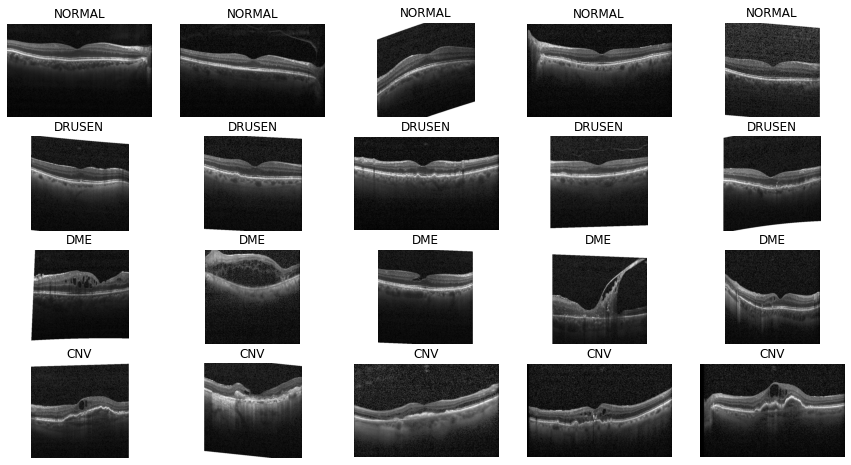

In [ ]:
labels_folders = ['NORMAL', 'DRUSEN', 'DME', 'CNV']
num_img = 5

fig, ax = plt.subplots(len(labels_folders), num_img, figsize = (int(3*num_img), 2*len(labels_folders)))
for j in range(0, len(labels_folders)):
  label = labels_folders[j]
  path = '/content/OCT2017 /train/' + label + '/'
  lista_imagens = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
  for i in range(0, num_img):
      img_matrix = np.matrix(Image.open(path + lista_imagens[i]))
      ax[j][i].imshow(img_matrix, cmap='gray', vmin = 0, vmax = 255)
      ax[j][i].set_title(label)
      ax[j][i].set_axis_off()
plt.show()

# Analise do Dataset

In [ ]:
#Cria datafame com as informações dos arquivos do dataset (não precisa rodar de novo - salvo em CSV)

list_splits = ['train', 'val', 'test']
labels_folders = ['NORMAL', 'DRUSEN', 'DME', 'CNV']

df = pd.DataFrame(columns = ['Conjunto', 'Label_Pasta', 'Label_Arquivo', 'ID_Paciente', 'Num_Imagem'])

for k in range(0, len(list_splits)):
  conjunto = list_splits[k]
  for j in range(0, len(labels_folders)):
    label_pasta = labels_folders[j]
    path = '/content/OCT2017 /' + conjunto + '/' + label_pasta + '/'
    lista_imagens = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
    for i in range(0, len(lista_imagens)):
        df.loc[len(df)] = np.append([conjunto, label_pasta], lista_imagens[i][:-5].split('-'))

df.to_csv(path_notebook + 'dataset_imagens.csv', index = False)
display(df)

Conjunto Label_Pasta Label_Arquivo ID_Paciente Num_Imagem
0        train      NORMAL        NORMAL      122878          1
1        train      NORMAL        NORMAL     1171785         21
2        train      NORMAL        NORMAL     4480299          2
3        train      NORMAL        NORMAL     3762419         24
4        train      NORMAL        NORMAL     4665128         11
...        ...         ...           ...         ...        ...
84479     test         CNV           CNV      827677          1
84480     test         CNV           CNV     3080163          1
84481     test         CNV           CNV     1784116          1
84482     test         CNV           CNV     1305450          2
84483     test         CNV           CNV     3847391          1

[84484 rows x 5 columns]

In [ ]:
df = pd.read_csv(path_notebook + 'dataset_imagens.csv')

In [ ]:
#Função Auxiliar para criar o caminho da imagem com base das informações do dataframe que vamos criar
def cria_path_img(linha):
  path = linha['Conjunto'] + '/' + linha['Label_Pasta'] + '/' + linha['Label_Arquivo'] + '-' + str(linha['ID_Paciente']) + '-' + str(linha['Num_Imagem']) + '.jpeg'
  return path

classes = ['CNV','DME','DRUSEN', 'NORMAL']

#Função Auxiliar para criar o caminho da imagem com base das informações do dataframe que vamos criar
def one_hot_encoder(y):
  if(y == 'CNV'):
    return [1, 0, 0, 0]
  elif(y == 'DME'):
    return [0, 1, 0, 0]
  elif(y == 'DRUSEN'):
    return [0, 0, 1, 0]
  elif(y == 'NORMAL'):
    return [0, 0, 0, 1]

#Função para inverter o One Hot Encoder
def inverse_one_hot_encoder_labels(y):
  if(np.argmax(y) == 0):
    return 'CNV'
  elif(np.argmax(y) == 1):
    return 'DME'
  elif(np.argmax(y) == 2):
    return 'DRUSEN'
  elif(np.argmax(y) == 3):
    return 'NORMAL'

def numeric_to_string(y):
  if(y == 0):
    return 'CNV'
  elif(y == 1):
    return 'DME'
  elif(y == 2):
    return 'DRUSEN'
  elif(y == 3):
    return 'NORMAL'

In [ ]:
#Checa a quantidade de imagens (tem 84484 e não 84495 como diz o kaggle!!)
print(len(df))

84484


In [ ]:
#Checa se tem Labels incoerentes entre o nome da pasta e o nome do arquivo (Não tem!!)
print(np.sum(df['Label_Pasta'] != df['Label_Arquivo']))

0


In [ ]:
def f(x):
  d = {}
  d['QTD_Arquivos_Imgs'] = len(x)
  d['QTD_Num_Imagens'] = len(x['Num_Imagem'].unique())
  d['QTD_train'] = np.sum(x['Conjunto'] == 'train')
  d['QTD_val'] = np.sum(x['Conjunto'] == 'val')
  d['QTD_test'] = np.sum(x['Conjunto'] == 'test')
  d['QTD_NORMAL'] = np.sum(x['Label_Arquivo'] == 'NORMAL')
  d['QTD_DME'] = np.sum(x['Label_Arquivo'] == 'DME')
  d['QTD_DRUSEN'] = np.sum(x['Label_Arquivo'] == 'DRUSEN')
  d['QTD_CNV'] = np.sum(x['Label_Arquivo'] == 'CNV')
  return pd.Series(d)

df_agrup = df.groupby('ID_Paciente').apply(lambda x: f(x))

In [ ]:
#Quantidade de ID_Paciente distintos
print(len(df_agrup))

4657


In [ ]:
#Pacientes que mais tem arquivos de imagens
df_agrup.sort_values('QTD_Arquivos_Imgs', ascending = False)[:10]

QTD_Arquivos_Imgs  QTD_Num_Imagens  ...  QTD_DRUSEN  QTD_CNV
ID_Paciente                                      ...                     
1188386                    817              813  ...           0      817
6652117                    614              613  ...           0      614
6666538                    585              585  ...           0      585
172472                     470              459  ...           0      470
7907754                    469              469  ...           0      469
9374492                    459              459  ...           0      459
1699976                    444              396  ...           0      401
1112835                    407              382  ...          23      384
9642260                    382              315  ...          66      315
1997439                    377              230  ...         140      237

[10 rows x 9 columns]

In [ ]:
#Paciente estranho
df[df['ID_Paciente'] == 1112835].groupby(['ID_Paciente', 'Num_Imagem']).apply(lambda x: f(x)).sort_values('QTD_Arquivos_Imgs', ascending = False)[:10]

QTD_Arquivos_Imgs  QTD_Num_Imagens  ...  QTD_DRUSEN  QTD_CNV
ID_Paciente Num_Imagem                                      ...                     
1112835     1                           4                1  ...           2        2
            2                           3                1  ...           1        2
            13                          2                1  ...           1        1
            21                          2                1  ...           1        1
            20                          2                1  ...           1        1
            19                          2                1  ...           1        1
            18                          2                1  ...           1        1
            17                          2                1  ...           1        1
            16                          2                1  ...           1        1
            15                          2                1  ...           1        1

[10 rows x 9 columns]

Conjunto  ...                                            Caminho
33296    train  ...  /content/OCT2017 /train/DRUSEN/DRUSEN-1112835-...
62133    train  ...     /content/OCT2017 /train/CNV/CNV-1112835-1.jpeg
83947     test  ...  /content/OCT2017 /test/DRUSEN/DRUSEN-1112835-1...
84354     test  ...      /content/OCT2017 /test/CNV/CNV-1112835-1.jpeg

[4 rows x 6 columns]

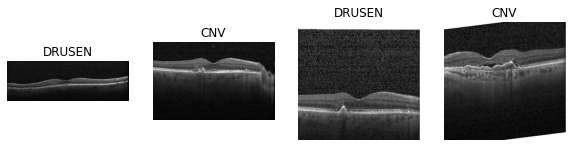

In [ ]:
#Imagens estranhas do paciente estranho

df_imgs = df[(df['ID_Paciente'] == 1112835) & (df['Num_Imagem'] == 1)].copy()
path_raiz = '/content/OCT2017 /'
df_imgs['Caminho'] = df_imgs.apply(lambda x: path_raiz + cria_path_img(x), axis = 1)
display(df_imgs)

num_img = len(df_imgs)
fig, ax = plt.subplots(1, num_img, figsize = [10, 5])
for i in range(0, num_img):
  path = df_imgs.iloc[i]['Caminho']
  label = df_imgs.iloc[i]['Label_Arquivo']
  img_matrix = np.matrix(Image.open(path))
  ax[i].imshow(img_matrix, cmap='gray', vmin = 0, vmax = 255)
  ax[i].set_title(label)
  ax[i].set_axis_off()
plt.show()

In [ ]:
#Pacientes "Honestos" no Teste
df_agrup[(df_agrup['QTD_train'] == 0) & (df_agrup['QTD_val'] == 0) & (df_agrup['QTD_test'] > 0)]

QTD_Arquivos_Imgs  QTD_Num_Imagens  ...  QTD_DRUSEN  QTD_CNV
ID_Paciente                                      ...                     
11053                        1                1  ...           0        0
70266                        3                3  ...           0        0
1102486                      4                4  ...           0        0
1274315                      2                2  ...           0        0
1430899                      1                1  ...           0        0
...                        ...              ...  ...         ...      ...
9109143                      1                1  ...           0        0
9211360                      2                2  ...           0        0
9241179                      1                1  ...           0        0
9378346                      3                3  ...           0        0
9488073                      2                2  ...           0        0

[63 rows x 9 columns]

# Refazendo a Distribuição dos Conjuntos (80/20 - Removendo Pacientes Intrusos)
#OBS: Mantendo Pacientes distintos em Treino/Validação e Estratificado

In [ ]:
df_paths = df.copy()

In [ ]:
#O conjunto de teste vai ficar o mesmo
#OBS: Os pacientes intrusos no treino ou na validação não serão colocados em um conjunto de Teste Complementar
#Tem 968 imagens no teste e não 1000 (o que aconteceu?)

df_paths['Novo_Conjunto'] = np.nan

df_paths.loc[df_paths['Conjunto'] == 'test', 'Novo_Conjunto'] = 'test'

#Lista de Pacientes que aparecem no Teste mas também aparecem no Treino ou na Validação
id_pacientes_intrusos = df_agrup[(df_agrup['QTD_test'] > 0) & ((df_agrup['QTD_train'] > 0) | (df_agrup['QTD_val'] > 0))].index.values

#Cria um conjunto de Teste Complementar
df_paths.loc[((df_paths['Conjunto'] == 'train') | (df_paths['Conjunto'] == 'val')) 
             & (df_paths['ID_Paciente'].isin(id_pacientes_intrusos)), 'Novo_Conjunto'] = 'test_compl'

print(len(df_paths[df_paths['Novo_Conjunto'] == 'test']))
print(len(df_paths[df_paths['Novo_Conjunto'] == 'test_compl']))

968
27693


In [ ]:
#Separa o treino e validação entre o restante com 80/20 mantendo a mesma proporção das classes nos 2 conjuntos
#E garantindo pacientes distintos em cada conjunto

df_aux = df_paths[df_paths['Novo_Conjunto'].isna()]
prop_classes = dict(df_aux['Label_Arquivo'].value_counts(normalize = True))

#Agrupamento por paciente
def h(x):
  d = {}
  d['QTD_Arquivos'] = len(x)
  d['QTD_NORMAL'] = np.sum(x['Label_Arquivo'] == 'NORMAL')
  d['QTD_DME'] = np.sum(x['Label_Arquivo'] == 'DME')
  d['QTD_DRUSEN'] = np.sum(x['Label_Arquivo'] == 'DRUSEN')
  d['QTD_CNV'] = np.sum(x['Label_Arquivo'] == 'CNV')
  return pd.Series(d)

df_agrup_aux = df_aux.groupby('ID_Paciente').apply(lambda x: h(x)).reset_index()
df_agrup_aux = df_agrup_aux.sort_values('QTD_Arquivos').reset_index(drop = True)

In [ ]:
#Encontra qual a classe que mais está longe da proporção esperada em um dataframe (de treino ou validação)
def classe_faltante(df, prop_classes, classes):
  tot = np.sum(df['QTD_Arquivos'])
  if(tot > 0):
    d = {'CNV': np.sum(df['QTD_CNV'])/tot,
        'DME': np.sum(df['QTD_DME'])/tot,
        'DRUSEN': np.sum(df['QTD_DRUSEN'])/tot,
        'NORMAL': np.sum(df['QTD_NORMAL'])/tot}
    classe_falt = classes[np.argmax([prop_classes[c] - d[c] for c in classes])]
    if(prop_classes[classe_falt] > d[classe_falt]):
      return classe_falt
    else:
      #Se não encontrar uma classe faltante, retorna a classe mais presente no dataset
      return classes[np.argmax([d[c] for c in classes])]
  else:
    #Se o dataset está vazio ainda, retorna a classe que queremos que seja a mais presente
    return classes[np.argmax([prop_classes[c] for c in classes])]

#Encontra o primeiro paciente que tem a classe desejada (no caso será a classe faltante a desejada)
def encontra_exemplo_classe(df_agrup_aux, indices, classe):
  df_temp = df_agrup_aux.loc[indices]
  i = 0
  qtd_classe = df_temp.iloc[0]['QTD_' + classe]
  while(i < len(df_temp)-1 and qtd_classe == 0):
    i = i + 1
    qtd_classe = df_temp.iloc[i]['QTD_' + classe]
  if(qtd_classe > 0):
    return i
  else:
    #OBS: Se não achar a classe desejada, retorna o primeiro paciente da lista
    return 0

#Define a fração que queremos dos dados na validação
frac_val = 0.2

#Algoritmo para distribuir os pacientes em treino e validação respeitando a fração escolhida
#E tentando manter a mesma proporção entre as classes do conjunto total
frac_train = 1 - frac_val
indices = list(df_agrup_aux.index)
df_train = pd.DataFrame(columns = df_agrup_aux.columns)
df_val = pd.DataFrame(columns = df_agrup_aux.columns)
for i in range(0, len(indices)):
  if(i == 0):
    df_train.loc[len(df_train)] = df_agrup_aux.loc[indices[i]]
    del indices[i]
  else:
    if(np.sum(df_train['QTD_Arquivos'])/frac_train > np.sum(df_val['QTD_Arquivos'])/frac_val):
      classe_ref = classe_faltante(df_val, prop_classes, classes)
      i_ref = encontra_exemplo_classe(df_agrup_aux, indices, classe_ref)
      df_val.loc[len(df_val)] = df_agrup_aux.iloc[indices[i_ref]]
      del indices[i_ref]
    else:
      classe_ref = classe_faltante(df_train, prop_classes, classes)
      i_ref = encontra_exemplo_classe(df_agrup_aux, indices, classe_ref)
      df_train.loc[len(df_train)] = df_agrup_aux.iloc[indices[i_ref]]
      del indices[i_ref]

In [ ]:
pacientes_train = list(df_train['ID_Paciente'])
pacientes_val = list(df_val['ID_Paciente'])
df_paths.loc[df_paths['ID_Paciente'].isin(pacientes_train), 'Novo_Conjunto'] = 'train'
df_paths.loc[df_paths['ID_Paciente'].isin(pacientes_val), 'Novo_Conjunto'] = 'val'

display(df_paths[df_paths['Novo_Conjunto'] == 'train']['Label_Arquivo'].value_counts(normalize = True))
display(df_paths[df_paths['Novo_Conjunto'] == 'val']['Label_Arquivo'].value_counts(normalize = True))

NORMAL    0.410286
CNV       0.394852
DME       0.124188
DRUSEN    0.070673
Name: Label_Arquivo, dtype: float64

CNV       0.424023
NORMAL    0.390752
DME       0.121635
DRUSEN    0.063590
Name: Label_Arquivo, dtype: float64

In [ ]:
#Distribuição de exemplos entre os novos conjuntos criados
df_paths['Novo_Conjunto'].value_counts()

train         44642
test_compl    27693
val           11181
test            968
Name: Novo_Conjunto, dtype: int64

In [ ]:
#Distribuição das Classes nos Testes
display(df_paths[df_paths['Novo_Conjunto'] == 'test']['Label_Arquivo'].value_counts())
display(df_paths[(df_paths['Novo_Conjunto'] == 'test_compl')]['Label_Arquivo'].value_counts())

CNV       242
DME       242
NORMAL    242
DRUSEN    242
Name: Label_Arquivo, dtype: int64

CNV       14845
DRUSEN     4758
DME        4452
NORMAL     3638
Name: Label_Arquivo, dtype: int64

In [ ]:
#Cria o caminho das imagens (path)
path_raiz = '/content/OCT2017 /'
df_paths['Caminho'] = df_paths.apply(lambda x: path_raiz + cria_path_img(x), axis = 1)

In [ ]:
display(df_paths)

Conjunto  ...                                            Caminho
0        train  ...  /content/OCT2017 /train/NORMAL/NORMAL-5699128-...
1        train  ...  /content/OCT2017 /train/NORMAL/NORMAL-7641896-...
2        train  ...  /content/OCT2017 /train/NORMAL/NORMAL-8099138-...
3        train  ...  /content/OCT2017 /train/NORMAL/NORMAL-4055810-...
4        train  ...  /content/OCT2017 /train/NORMAL/NORMAL-3997725-...
...        ...  ...                                                ...
84479     test  ...      /content/OCT2017 /test/CNV/CNV-2959614-3.jpeg
84480     test  ...      /content/OCT2017 /test/CNV/CNV-1632795-1.jpeg
84481     test  ...      /content/OCT2017 /test/CNV/CNV-4244160-3.jpeg
84482     test  ...      /content/OCT2017 /test/CNV/CNV-1699976-1.jpeg
84483     test  ...      /content/OCT2017 /test/CNV/CNV-1415351-1.jpeg

[84484 rows x 7 columns]

# Análise dos Pacientes nos Novos Conjuntos

In [ ]:
#Agrupamento para analisar o dataset por paciente após a nova distribuição dos conjuntos
def g(x):
  d = {}
  d['QTD_Arquivos_Imgs'] = len(x)
  d['QTD_Num_Imagens'] = len(x['Num_Imagem'].unique())
  d['QTD_train'] = np.sum(x['Novo_Conjunto'] == 'train')
  d['QTD_val'] = np.sum(x['Novo_Conjunto'] == 'val')
  d['QTD_test'] = np.sum(x['Novo_Conjunto'] == 'test')
  d['QTD_NORMAL'] = np.sum(x['Label_Arquivo'] == 'NORMAL')
  d['QTD_DME'] = np.sum(x['Label_Arquivo'] == 'DME')
  d['QTD_DRUSEN'] = np.sum(x['Label_Arquivo'] == 'DRUSEN')
  d['QTD_CNV'] = np.sum(x['Label_Arquivo'] == 'CNV')
  return pd.Series(d)

df_agrup_novo = df_paths.groupby('ID_Paciente').apply(lambda x: g(x))

In [ ]:
#Checa se agora realmente não temos pacientes do teste em outros conjuntos (não tem)
df_agrup_novo[(df_agrup_novo['QTD_test'] > 0) & ((df_agrup_novo['QTD_train'] > 0) | (df_agrup_novo['QTD_val'] > 0))]

Empty DataFrame
Columns: [QTD_Arquivos_Imgs, QTD_Num_Imagens, QTD_train, QTD_val, QTD_test, QTD_NORMAL, QTD_DME, QTD_DRUSEN, QTD_CNV]
Index: []

In [ ]:
#Checa agora se também o treino e a validação agora estão com pacientes distintos
display(df_agrup_novo[(df_agrup_novo['QTD_train'] > 0) & ((df_agrup_novo['QTD_test'] > 0) | (df_agrup_novo['QTD_val'] > 0))])
display(df_agrup_novo[(df_agrup_novo['QTD_val'] > 0) & ((df_agrup_novo['QTD_train'] > 0) | (df_agrup_novo['QTD_test'] > 0))])

Empty DataFrame
Columns: [QTD_Arquivos_Imgs, QTD_Num_Imagens, QTD_train, QTD_val, QTD_test, QTD_NORMAL, QTD_DME, QTD_DRUSEN, QTD_CNV]
Index: []

Empty DataFrame
Columns: [QTD_Arquivos_Imgs, QTD_Num_Imagens, QTD_train, QTD_val, QTD_test, QTD_NORMAL, QTD_DME, QTD_DRUSEN, QTD_CNV]
Index: []

In [ ]:
df_paths.to_csv(path_notebook + 'dataset_imagens_split.csv', index = False)

In [ ]:
df_paths = pd.read_csv(path_notebook + 'dataset_imagens_split.csv')

# Criação dos ImageGenerator para o AutoEncoder

In [ ]:
def elimina_bordas_brancas(img_matrix):
  limiar = 0.001
  nivel_branco = 250
  altura = img_matrix.shape[0]
  largura = img_matrix.shape[1]
  linha_max = int(altura/2)
  coluna_max = int(largura/2)

  #Filtra a parte superior da imagem
  i = 0
  frac_branco = 1
  while(frac_branco > limiar and i < linha_max):
    flag_filtro = img_matrix[i, :] >= nivel_branco
    frac_branco = np.sum(flag_filtro)/len(flag_filtro)
    if(frac_branco >= limiar):
      img_matrix[i, np.where(flag_filtro)] = 0
    i = i + 1

  #Filtra a parte inferior da imagem
  i = 0
  frac_branco = 1
  while(frac_branco > limiar and i < linha_max):
    flag_filtro = img_matrix[altura-1-i, :] >= nivel_branco
    frac_branco = np.sum(flag_filtro)/len(flag_filtro)
    if(frac_branco >= limiar):
      img_matrix[altura-1-i, np.where(flag_filtro)] = 0
    i = i + 1

  #Filtra a parte esquerda da imagem
  i = 0
  frac_branco = 1
  while(frac_branco > limiar and i < coluna_max):
    flag_filtro = img_matrix[:, i] >= nivel_branco
    frac_branco = np.sum(flag_filtro)/len(flag_filtro)
    if(frac_branco >= limiar):
      img_matrix[np.where(flag_filtro), i] = 0
    i = i + 1

  #Filtra a parte direita da imagem
  i = 0
  frac_branco = 1
  while(frac_branco > limiar and i < coluna_max):
    flag_filtro = img_matrix[:, largura-1-i] >= nivel_branco
    frac_branco = np.sum(flag_filtro)/len(flag_filtro)
    if(frac_branco >= limiar):
      img_matrix[np.where(flag_filtro), largura-1-i] = 0
    i = i + 1

  return img_matrix

In [ ]:
shape_reduzido = (512, 512)
batch_size = 16

datagen_autoencoder = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function = elimina_bordas_brancas,
    rescale = 1.0/255.0,
    rotation_range = 10,
    width_shift_range = 0.0, #Shifts grandes podem cortar áreas importantes lesão
    height_shift_range = 0.1,
    shear_range = 0.0, #distorção (pode distorcer a direção x e y de forma independente)
    zoom_range = 0.2, #zoom (pode dar zom na direção x e y de forma independente)
    horizontal_flip = True,
    vertical_flip = False,
    )

train_generator_autoencoder = datagen_autoencoder.flow_from_dataframe(
        df_paths[df_paths['Novo_Conjunto'] == 'train'], x_col = 'Caminho', y_col = 'Label_Arquivo',
        #classes = classes,
        target_size = shape_reduzido,
        color_mode = 'grayscale',
        batch_size = batch_size,
        class_mode = "input",
        #class_mode = 'categorical',
        #shuffle = False,
        )

valid_generator_autoencoder = datagen_autoencoder.flow_from_dataframe(
        df_paths[df_paths['Novo_Conjunto'] == 'val'], x_col = 'Caminho', y_col = 'Label_Arquivo',
        #classes = classes,
        target_size = shape_reduzido,
        color_mode = 'grayscale',
        batch_size = batch_size,
        class_mode = "input",
        #class_mode = 'categorical',
        #shuffle = False,
        )

steps_train_autoencoder = int(np.ceil(train_generator_autoencoder.samples/batch_size))
steps_val_autoencoder = int(np.ceil(valid_generator_autoencoder.samples/batch_size))

print(steps_train_autoencoder)
print(steps_val_autoencoder)

Found 44642 validated image filenames.
Found 11181 validated image filenames.
2791
699


Conjunto de Treino:


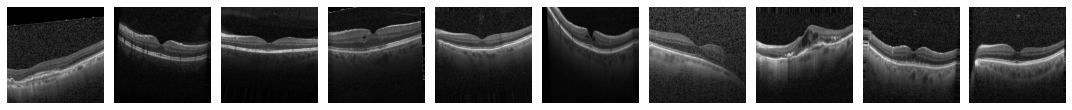

Conjunto de Validação:


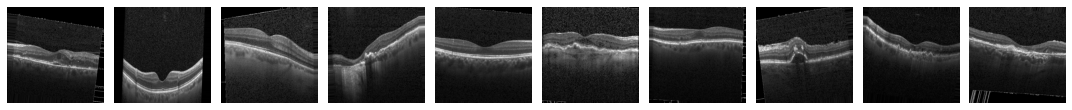

In [ ]:
num_row = 1
num_col = 10
num = num_row*num_col

print('Conjunto de Treino:')
fig, axes = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
exemplo_gen = next(train_generator_autoencoder)
X = exemplo_gen[0]
#y = exemplo_gen[1]
for i in range(num):
  ax = axes[i%num_col]
  ax.imshow(X[i, :, :, 0], cmap='gray', vmin = 0, vmax = 1)
  #ax.set_title(inverse_one_hot_encoder_labels(y[i]))
  ax.set_axis_off()
plt.tight_layout()
plt.show()

print('Conjunto de Validação:')
fig, axes = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
exemplo_gen = next(valid_generator_autoencoder)
X = exemplo_gen[0]
#y = exemplo_gen[1]
for i in range(num):
  ax = axes[i%num_col]
  ax.imshow(X[i, :, :, 0], cmap='gray', vmin = 0, vmax = 1)
  #ax.set_title(inverse_one_hot_encoder_labels(y[i]))
  ax.set_axis_off()
plt.tight_layout()
plt.show()

#Autoencoder

In [ ]:
#https://github.com/laurahanu/2D-and-3D-Deep-Autoencoder/blob/master/code/cae2d.py

encoding_dim = 256
shape_encoded = (16, 16)

F = 16
filter_shape = (3, 3)

input_img = tf.keras.Input(shape = (shape_reduzido[0], shape_reduzido[1], 1))

x = tf.keras.layers.Conv2D(F*2, filter_shape, strides = 2, padding = "same")(input_img)
x = tf.keras.layers.LeakyReLU(alpha = 0.2)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Conv2D(F*4, filter_shape, strides = 2, padding = "same")(x)
x = tf.keras.layers.LeakyReLU(alpha = 0.2)(x)
x = tf.keras.layers.BatchNormalization()(x)
#x = tf.keras.layers.Conv2D(F*8, filter_shape, strides = 2, padding = "same")(x)
#x = tf.keras.layers.LeakyReLU(alpha = 0.2)(x)
#x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Conv2D(F*8, filter_shape, strides = 2, padding = "same")(x)
x = tf.keras.layers.LeakyReLU(alpha = 0.2)(x)
x = tf.keras.layers.BatchNormalization(name = 'shape_ref')(x)

##############################
# Parte comum a qualquer arquitetura de Autoencoder (permite dimensionar o espaço latente de forma arbitrária)
##############################

x = tf.keras.layers.Flatten(name = 'flatten')(x) # Adicionei para dar mais liberdade para escolher o número de dimensões no espaço latente
encoded = tf.keras.layers.Dense(encoding_dim, name = 'espaco_latente')(x)

# nesse ponto a representação é 128-dimensional (dado pelo encoding_dim)-> checar no summary

#Pega o número de neuronios na flatten, #pois precisamos reconstruí-los no decoder
num_flatten = tf.keras.Model(input_img, encoded).get_layer('flatten').output_shape[1] 
#Pega o shape que devemos transformar o flatten
shape_ref = tf.keras.Model(input_img, encoded).get_layer('shape_ref').output_shape[1:] 

x = tf.keras.layers.Dense(num_flatten)(encoded)
x = tf.keras.layers.Reshape(shape_ref)(x)

##############################
# Fim da parte comum
##############################

#x = tf.keras.layers.Conv2DTranspose(F*8, filter_shape, strides = 2, padding = "same")(x)
#x = tf.keras.layers.LeakyReLU(alpha = 0.2)(x)
#x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Conv2DTranspose(F*8, filter_shape, strides = 2, padding = "same")(x)
x = tf.keras.layers.LeakyReLU(alpha = 0.2)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Conv2DTranspose(F*4, filter_shape, strides = 2, padding = "same")(x)
x = tf.keras.layers.LeakyReLU(alpha = 0.2)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Conv2DTranspose(F*2, filter_shape, strides = 2, padding = "same")(x)
x = tf.keras.layers.LeakyReLU(alpha = 0.2)(x)
x = tf.keras.layers.Conv2DTranspose(1, filter_shape, padding = "same")(x)
decoded = tf.keras.layers.Activation("sigmoid")(x)

autoencoder = tf.keras.Model(input_img, decoded)

opt = tf.keras.optimizers.Adam(learning_rate = 0.02)
autoencoder.compile(loss = 'mean_squared_error', optimizer = opt)

autoencoder.summary()

Model: "model_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         [(None, 512, 512, 1)]     0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 256, 256, 32)      320       
_________________________________________________________________
[... 40 linhas omitidas na versão pública ...]
conv2d_transpose_7 (Conv2DTr (None, 512, 512, 1)       289       
_________________________________________________________________
activation_1 (Activation)    (None, 512, 512, 1)       0         
Total params: 269,294,465
Trainable params: 269,293,633
Non-trainable params: 832
_________________________________________________________________


In [ ]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath = path_notebook + 'weights_autoencoder.h5',
    save_weights_only = True,
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True,
    verbose = 1)

epochs = 50
H = autoencoder.fit(train_generator_autoencoder, steps_per_epoch = int(steps_train_autoencoder/10), epochs = epochs, 
                    validation_data = valid_generator_autoencoder, validation_steps = int(steps_val_autoencoder/10),
                    callbacks = [model_checkpoint_callback])

joblib.dump(H.history, path_notebook + 'history_autoencoder.pkl')
gc.collect()

Epoch 1/50
279/279 [==============================] - 142s 505ms/step - loss: 0.0142 - val_loss: 0.0149

Epoch 00001: val_loss improved from inf to 0.01494, saving model to /content/drive/My Drive/<PASTA_DO_PROJETO>/Notebooks_Alexandre/04-Autoencoder/weights_autoencoder.h5
Epoch 2/50
279/279 [==============================] - 146s 522ms/step - loss: 0.0084 - val_loss: 0.0110

Epoch 00002: val_loss improved from 0.01494 to 0.01104, saving model to /content/drive/My Drive/<PASTA_DO_PROJETO>/Notebooks_Alexandre/04-Autoencoder/weights_autoencoder.h5
[... 184 linhas omitidas na versão pública ...]
Epoch 49/50
279/279 [==============================] - 129s 463ms/step - loss: 0.0444 - val_loss: 0.0438

Epoch 00049: val_loss did not improve from 0.00434
Epoch 50/50
279/279 [==============================] - 129s 462ms/step - loss: 0.0442 - val_loss: 0.0444

Epoch 00050: val_loss did not improve from 0.00434


631

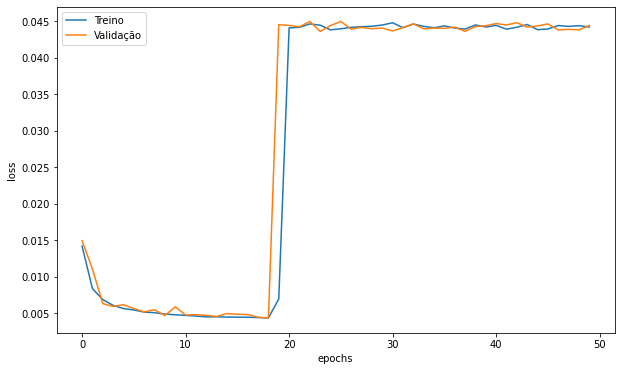

Loss Mínima: 0.004344595596194267
Época da Loss Mínima: 19


In [ ]:
autoencoder.load_weights(path_notebook + 'weights_autoencoder.h5')
encoder = tf.keras.Model(input_img, encoded)
history = joblib.load(path_notebook + 'history_autoencoder.pkl')

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)                 
ax.plot(history['loss'], label = 'Treino')
ax.plot(history['val_loss'], label = 'Validação')
ax.set_xlabel('epochs')
ax.set_ylabel('loss')
ax.legend()
plt.show()

print('Loss Mínima: ' + str(np.min(history['val_loss'])))
print('Época da Loss Mínima: ' + str(1 + np.argmin(history['val_loss'])))

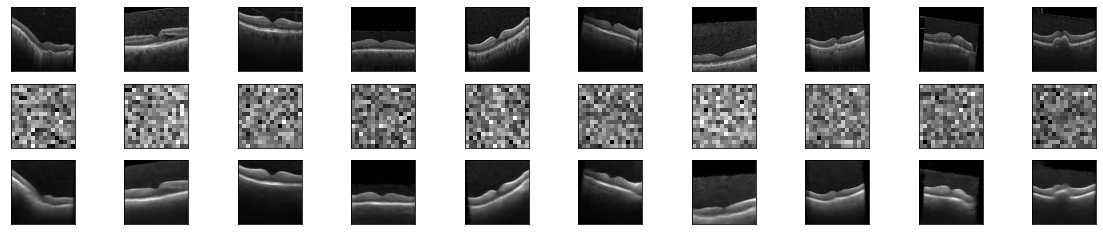

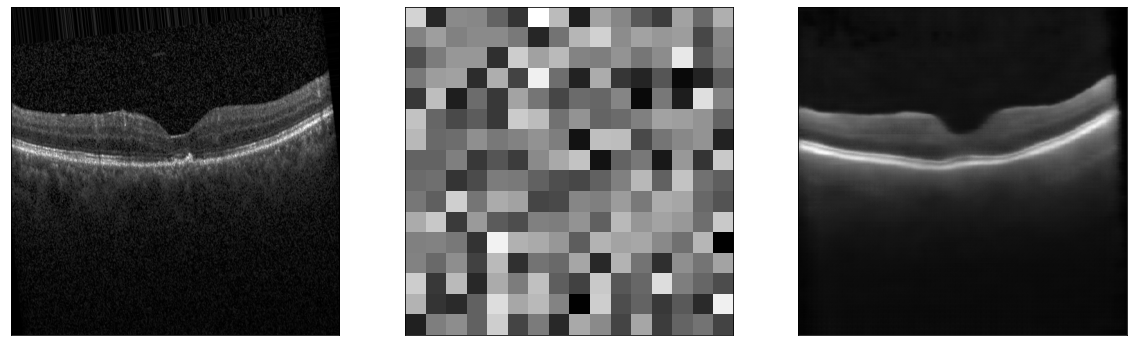

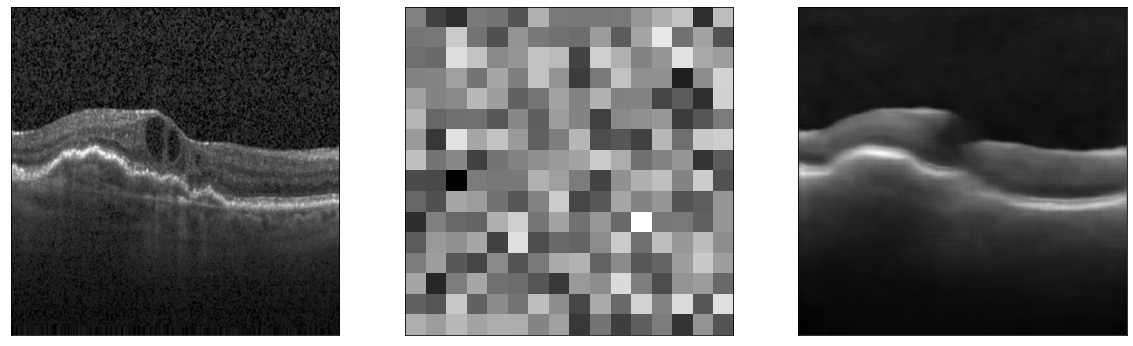

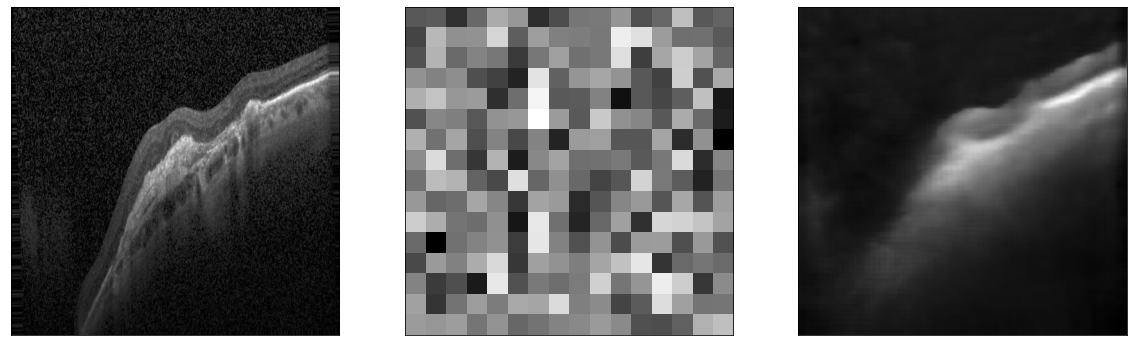

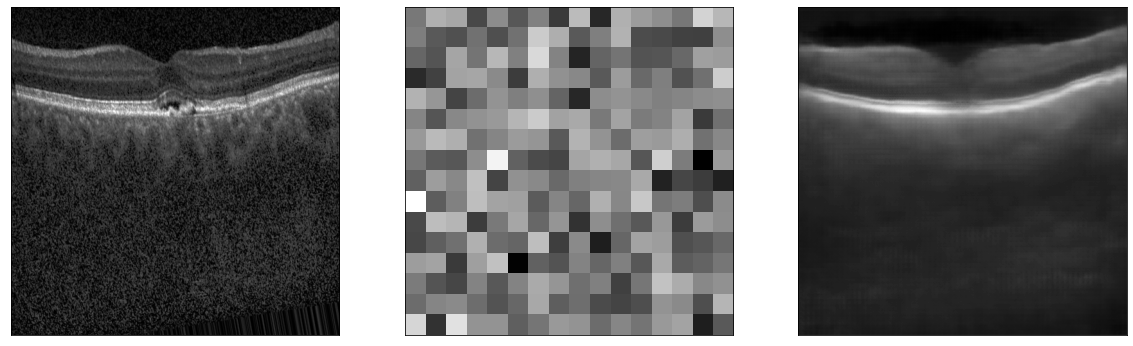

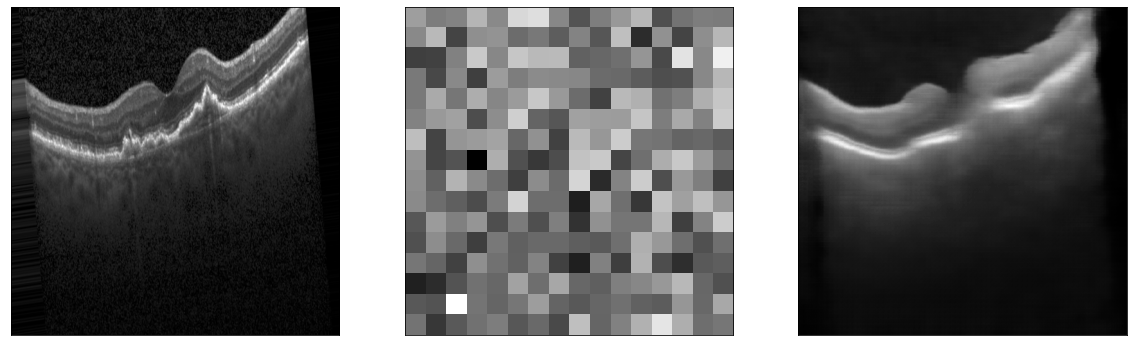

In [ ]:
x_exemplos = next(train_generator_autoencoder)[0]
decoded_imgs = autoencoder.predict(x_exemplos)
encoded_imgs = encoder.predict(x_exemplos)

n = 10
plt.figure(figsize=(20, 4))
for i in range(1, n + 1):
    # Display original
    ax = plt.subplot(3, n, i)

    plt.imshow(x_exemplos[i].reshape(shape_reduzido))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    #Display encoded
    ax = plt.subplot(3, n, i + n)
    plt.imshow(encoded_imgs[i].reshape(shape_encoded))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(3, n, i + 2*n)
    plt.imshow(decoded_imgs[i].reshape(shape_reduzido))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

k = 5
for i in range(n+1, n+1+k):
  plt.figure(figsize=(20, 10))

  ax = plt.subplot(1, 3, 1)
  plt.imshow(x_exemplos[i].reshape(shape_reduzido))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  ax = plt.subplot(1, 3, 2)
  plt.imshow(encoded_imgs[i].reshape(shape_encoded))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  ax = plt.subplot(1, 3, 3)
  plt.imshow(decoded_imgs[i].reshape(shape_reduzido))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  plt.show()

# Extração de Características

In [ ]:
featurenet = encoder
featurenet.summary()

featurenet_output_shape = featurenet.layers[-1].get_output_shape_at(0)
shape_featurenet_flat = np.prod(featurenet_output_shape[1:])
print(shape_featurenet_flat)

Model: "model_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         [(None, 512, 512, 1)]     0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 256, 256, 32)      320       
_________________________________________________________________
leaky_re_lu_6 (LeakyReLU)    (None, 256, 256, 32)      0         
_________________________________________________________________
batch_normalization_4 (Batch (None, 256, 256, 32)      128       
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 128, 128, 64)      18496     
_________________________________________________________________
leaky_re_lu_7 (LeakyReLU)    (None, 128, 128, 64)      0         
_________________________________________________________________
batch_normalization_5 (Batch (None, 128, 128, 64)      256 

In [ ]:
#Exemplo de Extração de Features em um Batch do ImageGenerator

exemplo_gen = next(train_generator_vanilla)
X = exemplo_gen[0]
X = np.repeat(X[:, :, :, 0, np.newaxis], 3, -1) #Faz virar imagens de 3 canais
y = exemplo_gen[1]

featurenet.predict(X).reshape(batch_size, shape_featurenet_flat)

NameError: ignored

In [ ]:
# Extração de Features direto dos arquivos das imagens
def extracao_features_baseline(df_paths, batch_size, featurenet):
  featurenet_output_shape = featurenet.layers[-1].get_output_shape_at(0)
  shape_featurenet_flat = np.prod(featurenet_output_shape[1:])
  
  x_conj = np.empty(shape = (0, shape_featurenet_flat))
  y_conj = np.array([])

  num_loop = int(np.ceil(len(df_paths)/batch_size))
  for i in range(0, num_loop):

    if(i < num_loop-1):
      paths = df_paths.iloc[i*batch_size:(i+1)*batch_size]['Caminho'].values
    else:
      paths = df_paths.iloc[i*batch_size:]['Caminho'].values

    batch = []
    for path in paths:
      #Carrega a Imagem e faz o preprocessamento (no caso é só reshape)
      X = np.array(Image.open(path))
      X = elimina_bordas_brancas(X)
      X = np.array(Image.fromarray(X).resize(shape_reduzido))
      X = X/255.0
      #OBS: lembrar que shapes de imagem são invertidos do shape de matrizes (linha, coluna) -> (coluna, linha)
      X = np.repeat(X[:, :, np.newaxis], 1, -1) #Faz virar imagens de 3 canais
      batch.append(X)
    batch = np.array(batch)

    x_conj = np.concatenate((x_conj, featurenet.predict(batch).reshape(len(batch), shape_featurenet_flat)), axis = 0)

    if(i < num_loop-1):
      y_conj = np.append(y_conj, df_paths.iloc[i*batch_size:(i+1)*batch_size]['Label_Arquivo'])
    else:
      y_conj = np.append(y_conj, df_paths.iloc[i*batch_size:]['Label_Arquivo'])

    del batch, X
    gc.collect()

  return x_conj, y_conj

In [ ]:
batch_size_iter = batch_size*(2**3)

In [ ]:
x_train, y_train = extracao_features_baseline(df_paths[df_paths['Novo_Conjunto'] == 'train'][['Caminho', 'Label_Arquivo']], 
                                              batch_size_iter, featurenet)
y_ohe_train = np.array([one_hot_encoder(y) for y in y_train])

x_val, y_val = extracao_features_baseline(df_paths[df_paths['Novo_Conjunto'] == 'val'][['Caminho', 'Label_Arquivo']], 
                                          batch_size_iter, featurenet)
y_ohe_val = np.array([one_hot_encoder(y) for y in y_val])

#Modelos Baseline: Rede Neural Fully-Connected

In [ ]:
input_shape = shape_featurenet_flat
output_shape = len(classes)

'''
model_baseline_nn = tf.keras.models.Sequential()
model_baseline_nn.add(tf.keras.layers.Dense(10, activation = 'relu', input_shape=(input_shape,)))
model_baseline_nn.add(tf.keras.layers.Dense(output_shape, activation = 'softmax'))
model_baseline_nn.summary()
'''

model_baseline_nn = tf.keras.models.Sequential()
model_baseline_nn.add(tf.keras.layers.Dense(output_shape, activation = 'softmax', input_shape=(input_shape,)))
model_baseline_nn.summary()

opt = tf.keras.optimizers.Adam(learning_rate = 0.001)
model_baseline_nn.compile(loss = 'categorical_crossentropy', optimizer = opt, metrics = ['accuracy'])

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_3 (Dense)              (None, 4)                 1028      
Total params: 1,028
Trainable params: 1,028
Non-trainable params: 0
_________________________________________________________________


In [ ]:
class_weights = compute_class_weight('balanced', classes, y_train)
train_class_weights = dict(enumerate(class_weights))
print(train_class_weights)

{0: 0.6331480115731548, 1: 2.0130772005772006, 2: 3.5374009508716324, 3: 0.6093306398777025}


In [ ]:
means_train = np.mean(x_train, axis = 0)
stds_train = np.std(x_train, axis = 0)
joblib.dump([means_train, stds_train], path_notebook + 'normalizacao_nn.pkl')

['/content/drive/My Drive/<PASTA_DO_PROJETO>/Notebooks_Alexandre/04-Autoencoder/normalizacao_nn.pkl']

In [ ]:
means_train, stds_train = joblib.load(path_notebook + 'normalizacao_nn.pkl')

In [ ]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath = path_notebook + 'weights.h5',
    save_weights_only = True,
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True,
    verbose = 1)

epochs = 50
H = model_baseline_nn.fit((x_train - means_train)/stds_train, y_ohe_train,
                          validation_data = ((x_val - means_train)/stds_train, y_ohe_val), 
                          class_weight = train_class_weights,
                          callbacks=[model_checkpoint_callback],
                          batch_size = batch_size, epochs = epochs, 
                          verbose = 1)

joblib.dump(H.history, path_notebook + 'history.pkl')
gc.collect()

Epoch 1/50
2791/2791 [==============================] - 7s 2ms/step - loss: 1.3077 - accuracy: 0.4421 - val_loss: 1.1282 - val_accuracy: 0.5364

Epoch 00001: val_loss improved from inf to 1.12822, saving model to /content/drive/My Drive/<PASTA_DO_PROJETO>/Notebooks_Alexandre/04-Autoencoder/weights.h5
Epoch 2/50
2791/2791 [==============================] - 7s 2ms/step - loss: 1.2246 - accuracy: 0.4986 - val_loss: 1.1267 - val_accuracy: 0.5248

Epoch 00002: val_loss improved from 1.12822 to 1.12668, saving model to /content/drive/My Drive/<PASTA_DO_PROJETO>/Notebooks_Alexandre/04-Autoencoder/weights.h5
[... 184 linhas omitidas na versão pública ...]
Epoch 49/50
2791/2791 [==============================] - 7s 2ms/step - loss: 1.1836 - accuracy: 0.5208 - val_loss: 1.0959 - val_accuracy: 0.5414

Epoch 00049: val_loss did not improve from 1.07696
Epoch 50/50
2791/2791 [==============================] - 7s 2ms/step - loss: 1.1818 - accuracy: 0.5230 - val_loss: 1.0825 - val_accuracy: 0.5561

E

4316

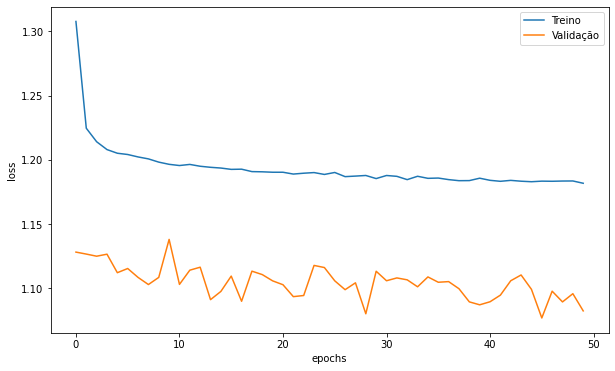

Loss Mínima: 1.0769649744033813
Época da Loss Mínima: 46


In [ ]:
model_baseline_nn.load_weights(path_notebook + 'weights.h5')
history = joblib.load(path_notebook + 'history.pkl')

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)                 
ax.plot(history['loss'], label = 'Treino')
ax.plot(history['val_loss'], label = 'Validação')
ax.set_xlabel('epochs')
ax.set_ylabel('loss')
ax.legend()
plt.show()

print('Loss Mínima: ' + str(np.min(history['val_loss'])))
print('Época da Loss Mínima: ' + str(1 + np.argmin(history['val_loss'])))

In [ ]:
def evaluate(y, preds, labels = None, normalize = True):
    # Cálculo das métricas de acerto.
    print('Accuracy:', metrics.accuracy_score(y, preds).round(3))
    print('Accuracy (balanced):', metrics.balanced_accuracy_score(y, preds).round(3))
    
    # Calculo da matriz de confusão.
    r = metrics.confusion_matrix(y, preds)
    if(normalize):
      r = r / r.sum(axis = 1, keepdims = True)
    
    #Evita Erro quando um dos Labels não está presente no conjunto y avaliado ou na predição
    labels_x = [l for l in labels if l in list(np.unique(preds))]
    labels_y = [l for l in labels if l in list(np.unique(y))]
    if(len(labels_x) >= len(labels_y)):
      labels = labels_x
    else:
      labels = labels_y

    # Impressão dos gráficos.
    if(normalize):
      (plt
      .figure(figsize=(8, 6))
      .suptitle('Matriz de confusão', fontsize=20))
      sns.heatmap(r,
                  cmap = "YlGnBu", linewidths = .5, annot = True, fmt = ".1%",
                  xticklabels = labels, yticklabels = labels, cbar = False)
    else:
      (plt
      .figure(figsize=(8, 6))
      .suptitle('Matriz de confusão', fontsize=20))
      sns.heatmap(r,
                  cmap = "YlGnBu", linewidths = .5, annot = True, fmt = "",
                  xticklabels = labels, yticklabels = labels, cbar = False)
    plt.show()

Treino:
Accuracy: 0.299
Accuracy (balanced): 0.37


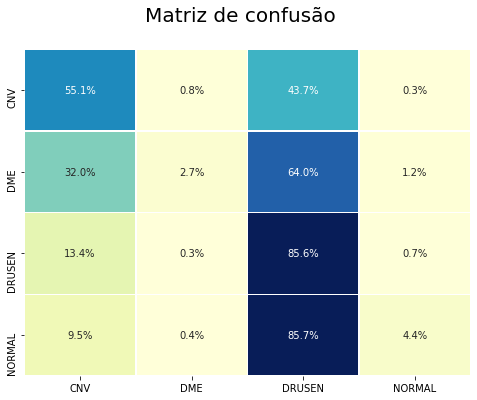

Validação:
Accuracy: 0.336
Accuracy (balanced): 0.36


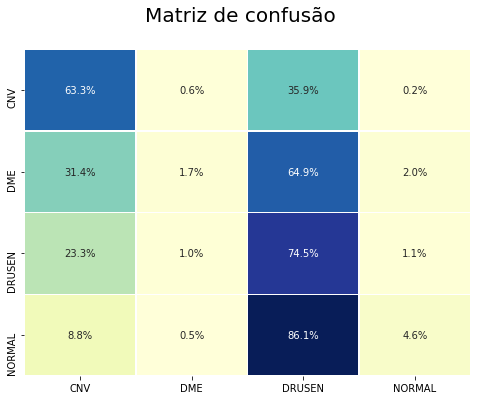

In [ ]:
print('Treino:')
evaluate(y_train, np.array([numeric_to_string(np.argmax(p)) for p in model_baseline_nn.predict(x_train)]), labels = classes)

print('Validação:')
evaluate(y_val, np.array([numeric_to_string(np.argmax(p)) for p in model_baseline_nn.predict(x_val)]), labels = classes)

#Modelos Baseline: Catboost

In [ ]:
!pip install catboost

     |████████████████████████████████| 69.2MB 75kB/s 


In [ ]:
from catboost import CatBoostClassifier

In [ ]:
class_weights = compute_class_weight('balanced', classes, y_train)
train_class_weights = dict([(classes[i],class_weights[i]) for i in range(0, len(classes))])
print(train_class_weights)

{'CNV': 0.561068189452469, 'DME': 1.83852504127683, 'DRUSEN': 2.421075518191042, 'NORMAL': 0.7931902364896951}


In [ ]:
clf_cat = CatBoostClassifier(class_weights = train_class_weights)

In [ ]:
clf_cat.fit(x_train, y_train, eval_set = (x_val, y_val), early_stopping_rounds = 50, verbose = True, plot = False)
joblib.dump(clf_cat, path_notebook + 'catboost.pkl')

history = {}
history['loss'] = clf_cat.get_evals_result()['learn']['MultiClass']
history['val_loss'] = clf_cat.get_evals_result()['validation']['MultiClass']

joblib.dump(history, path_notebook + 'history_cat.pkl')

Learning rate set to 0.117442
0:	learn: 1.3800207	test: 1.3803160	best: 1.3803160 (0)	total: 194ms	remaining: 3m 13s
1:	learn: 1.3749917	test: 1.3755737	best: 1.3755737 (1)	total: 314ms	remaining: 2m 36s
2:	learn: 1.3692358	test: 1.3703287	best: 1.3703287 (2)	total: 444ms	remaining: 2m 27s
3:	learn: 1.3638464	test: 1.3656381	best: 1.3656381 (3)	total: 594ms	remaining: 2m 27s
4:	learn: 1.3598781	test: 1.3624938	best: 1.3624938 (4)	total: 715ms	remaining: 2m 22s
5:	learn: 1.3559849	test: 1.3590461	best: 1.3590461 (5)	total: 856ms	remaining: 2m 21s
6:	learn: 1.3515822	test: 1.3552197	best: 1.3552197 (6)	total: 979ms	remaining: 2m 18s
[... 989 linhas omitidas na versão pública ...]
996:	learn: 0.5948909	test: 0.8787235	best: 0.8787235 (996)	total: 1m 53s	remaining: 340ms
997:	learn: 0.5944501	test: 0.8786875	best: 0.8786875 (997)	total: 1m 53s	remaining: 227ms
998:	learn: 0.5941632	test: 0.8785191	best: 0.8785191 (998)	total: 1m 53s	remaining: 113ms
999:	learn: 0.5938229	test: 0.8783976	be

['/content/drive/My Drive/<PASTA_DO_PROJETO>/Notebooks_Alexandre/history_cat02.pkl']

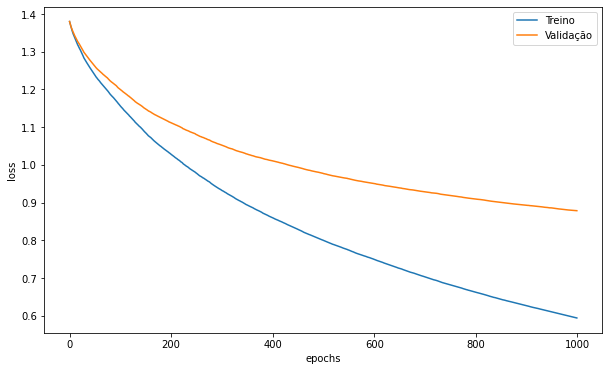

Loss Mínima: 0.8783975976545675
Época da Loss Mínima: 1000


In [ ]:
clf_cat = joblib.load(path_notebook + 'catboost.pkl')
history = joblib.load(path_notebook + 'history_cat.pkl')

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)                 
ax.plot(history['loss'], label = 'Treino')
ax.plot(history['val_loss'], label = 'Validação')
ax.set_xlabel('epochs')
ax.set_ylabel('loss')
ax.legend()
plt.show()

print('Loss Mínima: ' + str(np.min(history['val_loss'])))
print('Época da Loss Mínima: ' + str(1 + np.argmin(history['val_loss'])))

Treino:
Accuracy: 0.863
Accuracy (balanced): 0.872


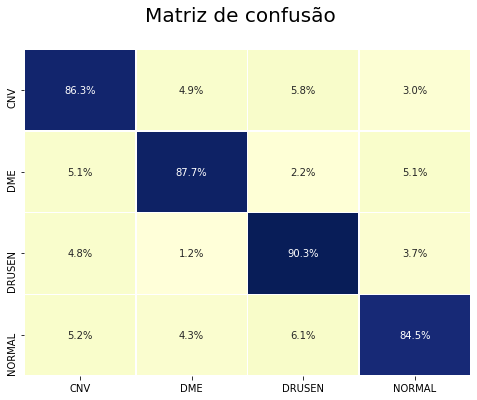

Validação:
Accuracy: 0.725
Accuracy (balanced): 0.674


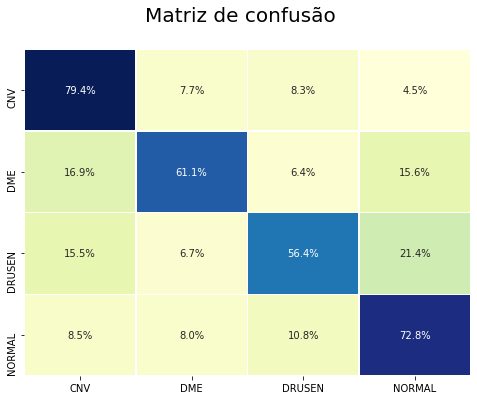

In [ ]:
print('Treino:')
evaluate(y_train, clf_cat.predict(x_train), labels = classes)

print('Validação:')
evaluate(y_val, clf_cat.predict(x_val), labels = classes)

# Avaliação no Teste

In [ ]:
x_test, y_test = extracao_features_baseline(df_paths[df_paths['Novo_Conjunto'] == 'test'][['Caminho', 'Label_Arquivo']], 
                                          batch_size_iter, featurenet)
y_ohe_test = np.array([one_hot_encoder(y) for y in y_test])

x_test_hon, y_test_hon = extracao_features_baseline(df_paths[(df_paths['Novo_Conjunto'] == 'test')&
                                                             (df_paths['Teste_Honesto'] == True)][['Caminho', 'Label_Arquivo']], 
                                          batch_size_iter, featurenet)
y_ohe_test_hon = np.array([one_hot_encoder(y) for y in y_test_hon])

Teste (Fully-Connected):
Accuracy: 0.442
Accuracy (balanced): 0.442


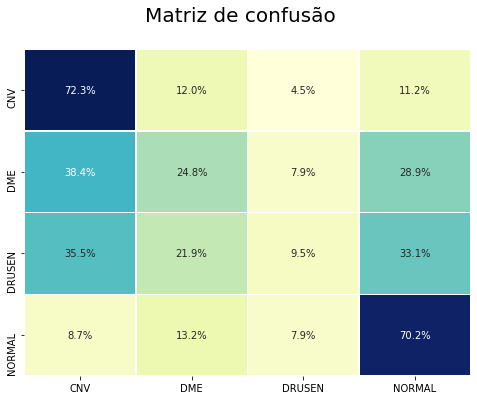

Teste Honesto (Fully-Connected):
Accuracy: 0.457
Accuracy (balanced): 0.615


/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1859: UserWarning: y_pred contains classes not in y_true
  warnings.warn('y_pred contains classes not in y_true')
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in true_divide
  if __name__ == '__main__':


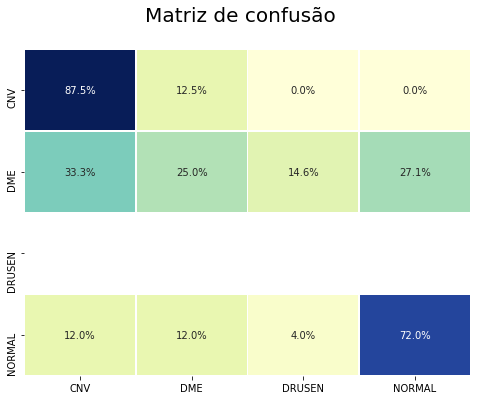

In [ ]:
print('Teste (Fully-Connected):')
evaluate(y_test, np.array([numeric_to_string(np.argmax(p)) for p in model_baseline_nn.predict(x_test)]), labels = classes)

print('Teste Honesto (Fully-Connected):')
evaluate(y_test_hon, np.array([numeric_to_string(np.argmax(p)) for p in model_baseline_nn.predict(x_test_hon)]), labels = classes)

Teste (Catboost):
Accuracy: 0.873
Accuracy (balanced): 0.873


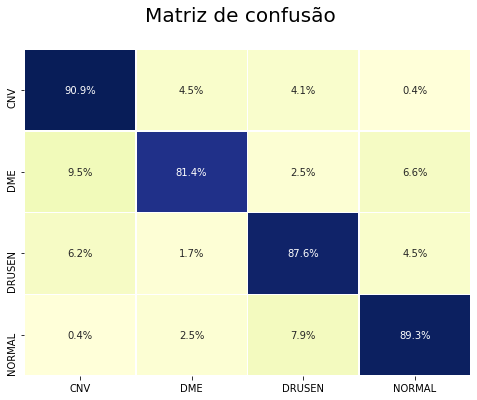

Teste Honesto (Catboost):
Accuracy: 0.765
Accuracy (balanced): 0.868


/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1859: UserWarning: y_pred contains classes not in y_true
  warnings.warn('y_pred contains classes not in y_true')
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in true_divide
  if __name__ == '__main__':


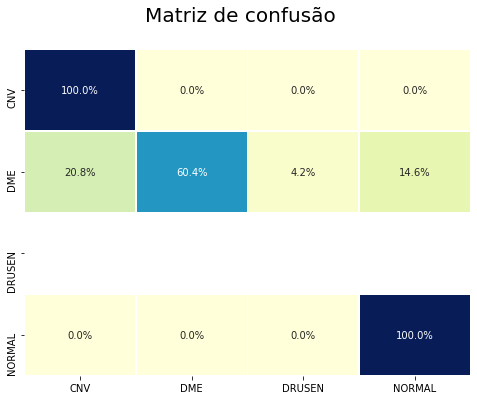

In [ ]:
print('Teste (Catboost):')
evaluate(y_test, clf_cat.predict(x_test), labels = classes)

print('Teste Honesto (Catboost):')
evaluate(y_test_hon, clf_cat.predict(x_test_hon), labels = classes)

Teste (Fully-Connected):
Accuracy: 0.442
Accuracy (balanced): 0.442


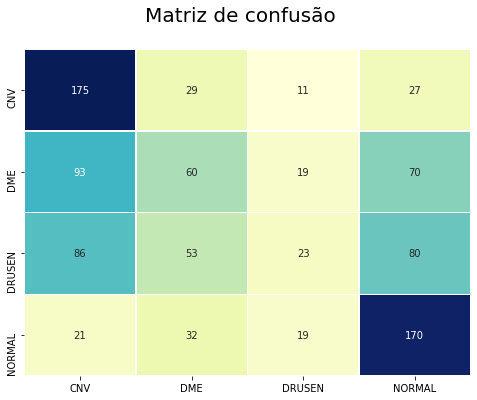

Teste (Catboost):
Accuracy: 0.873
Accuracy (balanced): 0.873


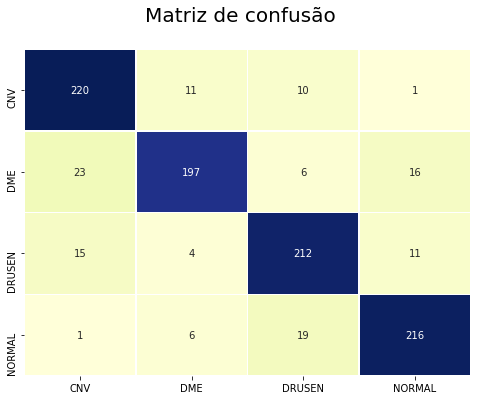

In [ ]:
print('Teste (Fully-Connected):')
evaluate(y_test, np.array([numeric_to_string(np.argmax(p)) for p in model_baseline_nn.predict(x_test)]), labels = classes, normalize = False)
print('Teste (Catboost):')
evaluate(y_test, clf_cat.predict(x_test), labels = classes, normalize = False)